In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/cleaned_sms.csv')

# Convert labels to numbers: spam=1, ham=0
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['cleaned']
y = df['label_num']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 4464
Testing samples:  1116


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_tfidf.shape}")

ValueError: np.nan is an invalid document, expected byte or unicode string.

In [4]:
# Check for problems
print("NaN values:", X_train.isnull().sum())
print("Empty strings:", (X_train.str.strip() == '').sum())

NaN values: 5
Empty strings: 0


In [5]:
# Drop NaN and empty strings from the full dataframe first
df = df.dropna(subset=['cleaned'])
df = df[df['cleaned'].str.strip() != '']

# Redo the split with the cleaned dataframe
X = df['cleaned']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Now retry TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_tfidf.shape}")

Feature matrix shape: (4459, 3000)


In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# class_weight='balanced' tells the model to pay more attention
# to the minority class (spam) during training
models = {
    "Naive Bayes":         MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM":                 LinearSVC(max_iter=2000, class_weight='balanced')
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    print(f"{name} trained ✓")

Naive Bayes trained ✓
Logistic Regression trained ✓
SVM trained ✓


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "F1 Score":  round(f1_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score
        Naive Bayes    0.9704     1.0000  0.7815    0.8773
Logistic Regression    0.9704     0.8688  0.9205    0.8939
                SVM    0.9794     0.9267  0.9205    0.9236


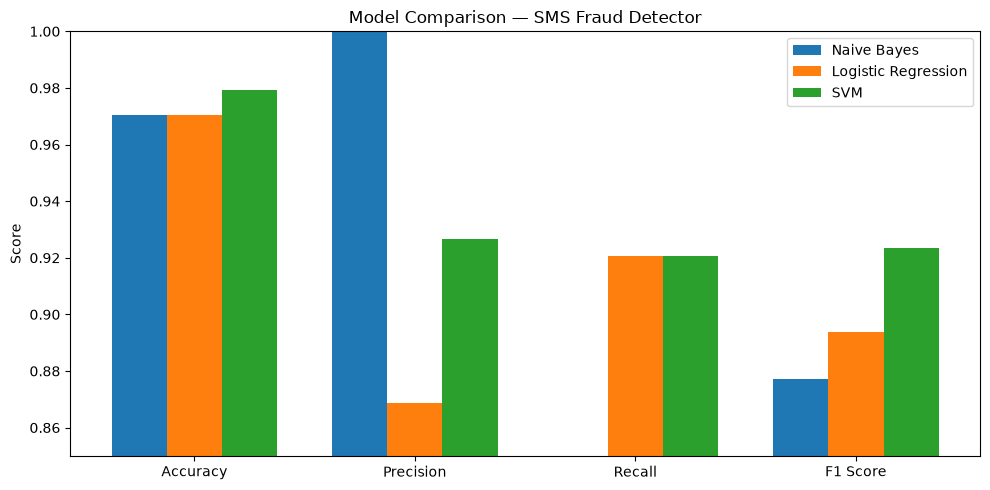

In [13]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, row in results_df.iterrows():
    ax.bar(x + i * width, row[metrics], width, label=row["Model"])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.0)
ax.set_title("Model Comparison — SMS Fraud Detector")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

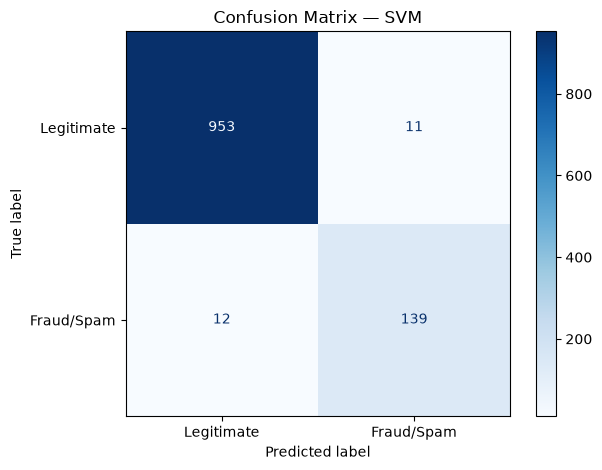

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = models["SVM"]
y_pred_best = best_model.predict(X_test_tfidf)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=["Legitimate", "Fraud/Spam"],
    cmap="Blues"
)
plt.title("Confusion Matrix — SVM")
plt.tight_layout()
plt.show()

In [16]:
import joblib

joblib.dump(best_model,  '../src/model.pkl')
joblib.dump(vectorizer,  '../src/vectorizer.pkl')

print("Model and vectorizer saved to src/ ✓")

Model and vectorizer saved to src/ ✓
